# TCLab_CLP_PID_FF

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
import tclab
import time
from datetime import datetime
import os

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import package_LAB
import package_DBR
from package_DBR import SelectPath_RT, Delay_RT, FO_RT
from package_LAB import LL_RT, PID_RT, IMC_Tuning, Margin

In [14]:
Ts = 1 
TSim = 3300
#TSim = 2500 #Pour expérience ajouter un délai test marge de phase
NumRTsteps = int(TSim/Ts) + 1

Kp, Tp1, Tp2, thetap = 0.36, 170.82, 26.55, 13.31
Kd, Td1, Td2, thetad = 0.31, 161.20, 32.3, 15.75
PV0, MV0, DV0 = 55, 50, 50

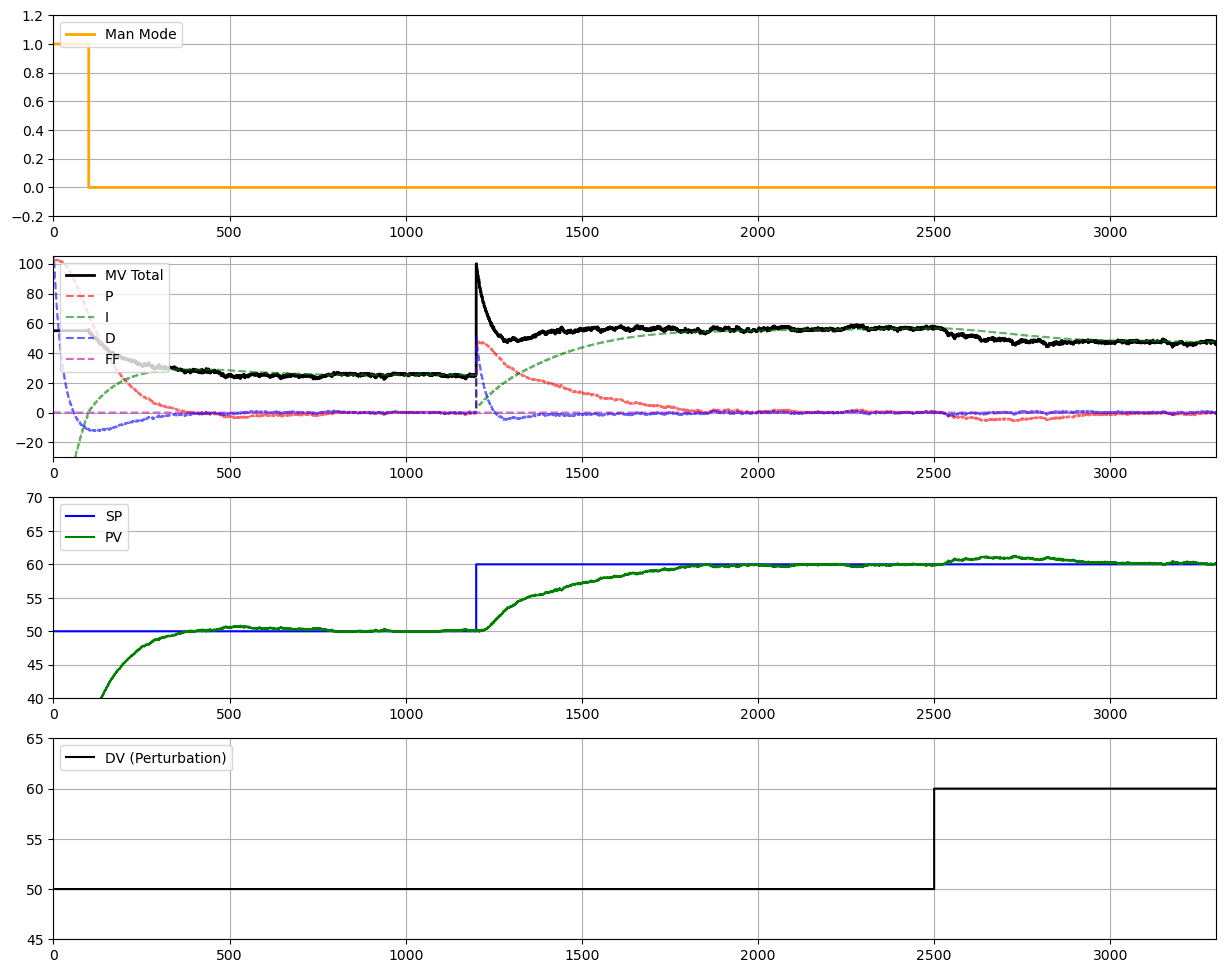

TCLab disconnected successfully.
Expérience terminée, TCLab déconnecté.


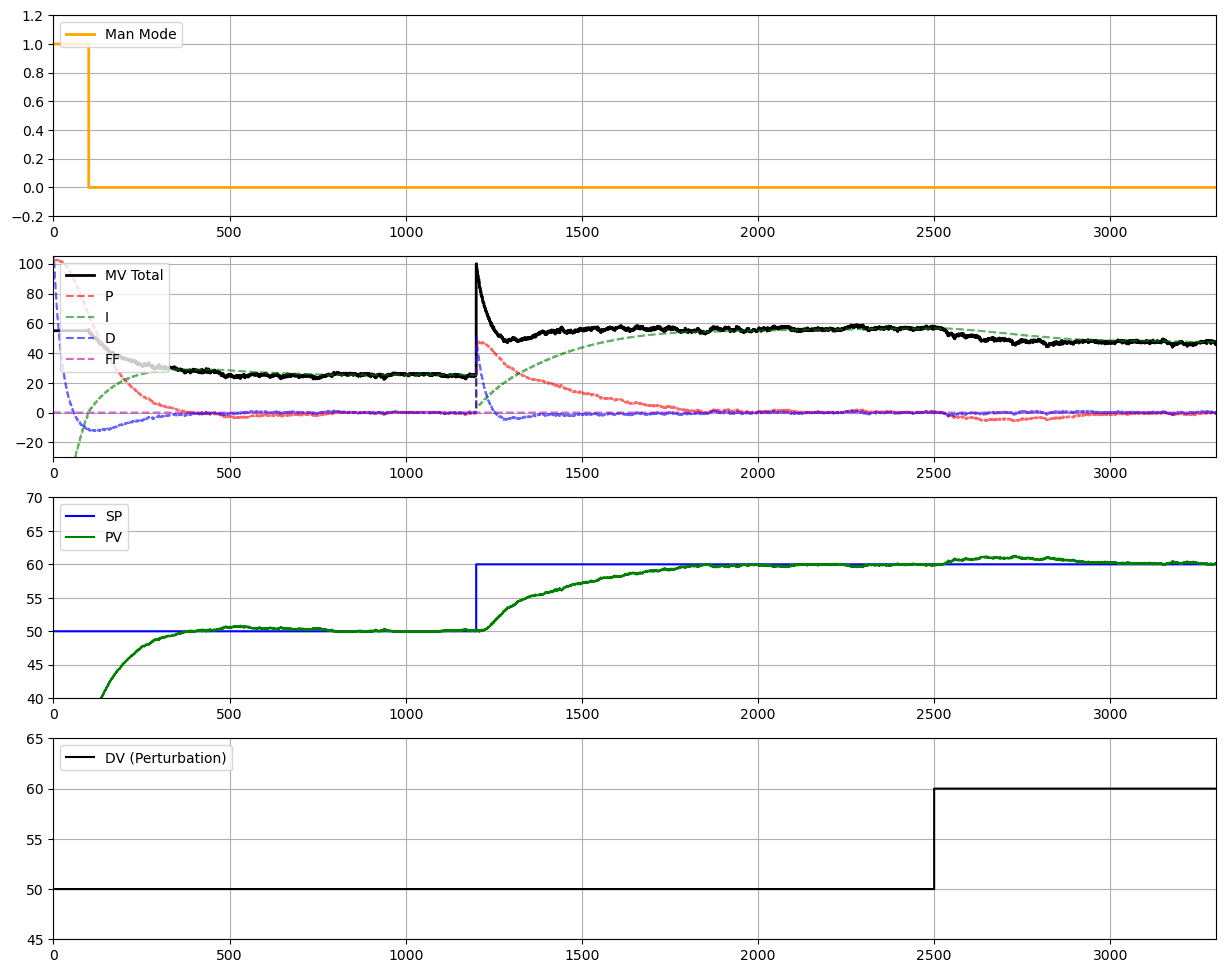

In [15]:
#L_add = 250 #Pour ajouter un délai test marge de phase
K_FF = -Kd / Kp
theta_FF = max(0, thetad - thetap)
gamma = 0.6
alpha = 0.9
booléan = False

Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=gamma*Tp1, model='SOPDT')
MVMin, MVMax = 0, 100


t, DV, DV_delta, DV_delay, MVFF_step1, MVFF = [], [], [], [], [], []
E, SP, Man, MVMan, MV, MVP, MVI, MVD, PV = [], [], [], [], [], [], [], [], []


DVPath = {0: 50, 2500: 60, TSim: 60}
SPPath = {0: 50, 1200: 60, TSim: 60}
ManPath = {0: True, 100: False, 1500: False, TSim: False}
#ManPath = {0: True, TSim: True}
MVManPath = {0: 55, TSim: 55}


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))
l_man, = ax1.step([], [], 'orange', lw=2, label='Man Mode', where='post')

l_mv, = ax2.step([], [], 'k-', lw=2, label='MV Total', where='post')
l_mvp, = ax2.step([], [], 'r--', alpha=0.6, label='P', where='post')
l_mvi, = ax2.step([], [], 'g--', alpha=0.6, label='I', where='post')
l_mvd, = ax2.step([], [], 'b--', alpha=0.6, label='D', where='post')
l_mvff, = ax2.step([], [], 'm--', alpha=0.6, label='FF', where='post')

l_sp, = ax3.step([], [], 'b-', label='SP', where='post')
l_pv, = ax3.step([], [], 'g-', label='PV', where='post')

l_dv, = ax4.step([], [], 'k-', label='DV (Perturbation)', where='post')

for ax in [ax1, ax2, ax3, ax4]: ax.grid(True); ax.legend(loc='upper left')


lab = tclab.TCLab()
print("TCLab Connecté. Début de l'expérience...")

try:
    for i in range(NumRTsteps):
        start_time = time.time()
        t.append(i * Ts)

        SelectPath_RT(DVPath, t, DV)
        SelectPath_RT(SPPath, t, SP)
        SelectPath_RT(ManPath, t, Man)
        SelectPath_RT(MVManPath, t, MVMan)
        
        PV.append(lab.T1)
        
        # if len(PV) > L_add:   #Pour le délai test marge de phase
        #     PV_feedback = [PV[-L_add-1]]
        # else:
        #     PV_feedback = [PV[-1]]
        
        DV_delta.append(DV[-1] - DV0)
        Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
        LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1, method='EBD')
        if booléan:
            LL_RT(MVFF_step1, 1.0, Tp2, Td2, Ts, MVFF, method='EBD')
        else:
            LL_RT(MVFF_step1, 0, Tp2, Td2, Ts, MVFF, method='EBD')
            
        PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, 
               MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF=booléan, PVInit=PV0)
        
        #PID_RT(SP, PV_feedback, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, 
        #       MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF=booléan, PVInit=PV0)   #Pour le délai test marge de phase, on utilise PV_feedback au lieu de PV
        
        lab.Q1(MV[-1])
        lab.Q2(DV[-1])
        
        if i % 5 == 0:
            l_man.set_data(t, [int(m) for m in Man])
            
            l_mv.set_data(t, MV)
            l_mvp.set_data(t, MVP)
            l_mvi.set_data(t, MVI)
            l_mvd.set_data(t, MVD)
            l_mvff.set_data(t, MVFF)
            
            l_sp.set_data(t, SP)
            l_pv.set_data(t, PV)
            l_dv.set_data(t, DV)
            
            for ax in [ax1, ax2, ax3, ax4]: ax.set_xlim(0, max(10, t[-1]))
            ax1.set_ylim(-0.2, 1.2); ax2.set_ylim(-30, 105); ax3.set_ylim(40, 70); ax4.set_ylim(min(DV)-5, max(DV)+5)
            
            clear_output(wait=True)
            display(fig)
        
        delta = time.time() - start_time
        time.sleep(max(0, Ts - delta))

finally:
    lab.close()
    print("Expérience terminée, TCLab déconnecté.")

now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")
nameFile = 'Data/RT_PID_FF_' + date_time + '.txt'
#nameFile = 'Data/RT_PID_delai_' + date_time + '.txt' #pour le délai test marge de phase

if not os.path.exists('Data'): os.makedirs('Data')

my_data = np.vstack((t, MV, MVP, MVI, MVD, MVFF, SP, PV, DV, [int(m) for m in Man], MVMan)).T
np.savetxt(nameFile, my_data, delimiter=',', 
           header='t,MV,MVP,MVI,MVD,MVFF,SP,PV,DV,Man,MVMan', comments='')

if not os.path.exists('Plots'): os.makedirs('Plots')
plt.savefig('Plots/RT_PID_FF_' + date_time + '.png')
#plt.savefig('Plots/RT_PID_delai_' + date_time + '.png') #pour le délai test marge de phase